# Benchmarking RK-PINNs

What does a loss evaluation cost, how does that cost scale, and what accuracy does each
Butcher tableau buy for it?

The interesting question is not raw speed. All three shipped tableaux are 2-stage, so
they cost the same per slab — but under `residual="rk"` they have classical orders 4, 3
and 2. This notebook measures both sides of that trade so the comparison is concrete.

**Contents**

1. Cost of a single loss evaluation, forward and backward
2. Scaling in the number of time slabs and in spatial batch size
3. Memory
4. CPU vs GPU
5. Accuracy per unit cost — the part that actually matters

**Runtime:** roughly 1–2 minutes on CPU.

In [1]:
import math
import platform
import time

import matplotlib.pyplot as plt
import torch

from pinn_rk import (
    MLP,
    Laplacian1D,
    RkPinnConfig,
    RkPinnLoss,
    TimeMesh,
    butcher_gauss_legendre_q2,
    butcher_lobatto_iiia_q2,
    butcher_radau_iia_q2,
)

%matplotlib inline
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

CPU = torch.device("cpu")
HAS_CUDA = torch.cuda.is_available()
print("torch     :", torch.__version__)
print("python    :", platform.python_version())
print("platform  :", platform.system(), platform.machine())
print("threads   :", torch.get_num_threads())
print("cuda      :", torch.cuda.get_device_name(0) if HAS_CUDA else "not available")

torch     : 2.11.0+cpu
python    : 3.13.5
platform  : Windows AMD64
threads   : 16
cuda      : not available


## Harness

Timings are wall-clock and machine-specific; treat the *ratios* as the signal, not the
absolute numbers.

Each measurement discards warm-up iterations and reports the **fastest** of several
repeats. That is deliberate: timing noise is strictly additive — scheduling, background
load and thermal effects can only make a run slower — so the minimum is the least
contaminated estimate available, whereas a mean mostly measures whatever else the
machine was doing.

In [2]:
TABLEAUX = {
    "gauss2": butcher_gauss_legendre_q2,
    "radau2": butcher_radau_iia_q2,
    "lobatto2": butcher_lobatto_iiia_q2,
}
CLASSICAL_ORDER = {"gauss2": 4, "radau2": 3, "lobatto2": 2}


def exact_u(x, t):
    return torch.sin(math.pi * x) * torch.exp(-(math.pi**2) * t)


def zero_rhs(x, t):
    return torch.zeros_like(x)


def make_loss(tableau="radau2", N=8, n_x=96, residual="rk", device=CPU, width=96):
    torch.manual_seed(0)
    x0 = torch.linspace(1e-6, 1 - 1e-6, 128, device=device).unsqueeze(1)
    cfg = RkPinnConfig(
        tableau=TABLEAUX[tableau](device),
        time_mesh=TimeMesh.uniform(T=0.1, N=N, device=device),
        residual=residual,
        n_x_train=n_x,
        device=device,
        init_data=(x0, exact_u(x0, torch.zeros_like(x0))),
    )
    model = MLP(width=width, depth=4, dtype=torch.float64).to(device)
    fn = RkPinnLoss(model=model, Lop=Laplacian1D(), f_rhs=zero_rhs, cfg=cfg).to(device)
    return model, fn


def sync(device):
    if device.type == "cuda":
        torch.cuda.synchronize()


def time_step(fn, model, device=CPU, backward=True, warmup=3, repeats=9):
    """Fastest observed seconds for one loss evaluation (optionally with backward).

    Reports the minimum rather than the mean or median. Timing noise on a shared
    machine is strictly additive -- scheduling and background load can only make a
    measurement slower -- so the fastest run is the least contaminated estimate of
    the true cost.
    """
    for _ in range(warmup):
        loss = fn()
        if backward:
            model.zero_grad(set_to_none=True)
            loss.backward()
    sync(device)

    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        loss = fn()
        if backward:
            model.zero_grad(set_to_none=True)
            loss.backward()
        sync(device)
        times.append(time.perf_counter() - t0)
    return min(times)

## 1. Cost of a loss evaluation

Backward is the dominant cost. The elliptic operator needs `u_xx`, built with
`create_graph=True`, so differentiating the loss means differentiating *through* an
autograd graph that already contains a derivative.

In [3]:
# One throwaway measurement first. Without it the first row absorbs allocator and
# kernel warm-up and reads several times slower than it should, which looks like a
# difference between tableaux when it is nothing of the sort.
_m, _f = make_loss()
time_step(_f, _m, warmup=3, repeats=3)

rows = []
for name in TABLEAUX:
    for residual in ("rk", "interpolant"):
        model, fn = make_loss(tableau=name, residual=residual)
        fwd = time_step(fn, model, backward=False)
        tot = time_step(fn, model, backward=True)
        rows.append((name, residual, fwd, tot, tot - fwd))

print(f"{'tableau':10} {'residual':12} {'forward':>10} {'fwd+bwd':>10} {'backward':>10}")
print("-" * 56)
for name, residual, fwd, tot, bwd in rows:
    print(f"{name:10} {residual:12} {fwd * 1e3:9.1f}ms {tot * 1e3:9.1f}ms {bwd * 1e3:9.1f}ms")

tableau    residual        forward    fwd+bwd   backward
--------------------------------------------------------
gauss2     rk                56.9ms     123.9ms      67.0ms
gauss2     interpolant       45.5ms      93.8ms      48.3ms
radau2     rk                48.1ms     132.0ms      84.0ms
radau2     interpolant       55.7ms      98.5ms      42.8ms
lobatto2   rk                61.8ms     147.2ms      85.4ms
lobatto2   interpolant       41.8ms     116.1ms      74.3ms


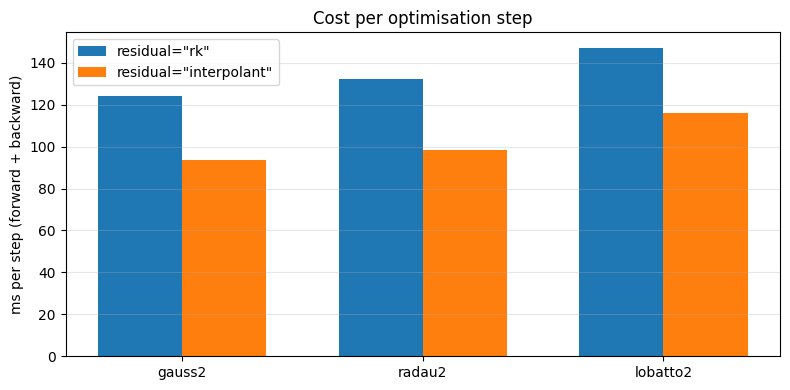

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(TABLEAUX)
width_ = 0.35
xpos = range(len(names))
for off, residual in ((-width_ / 2, "rk"), (width_ / 2, "interpolant")):
    vals = [next(t for n, r, _, t, _ in rows if n == nm and r == residual) * 1e3 for nm in names]
    ax.bar([x + off for x in xpos], vals, width_, label=f'residual="{residual}"')
ax.set_xticks(list(xpos))
ax.set_xticklabels(names)
ax.set_ylabel("ms per step (forward + backward)")
ax.set_title("Cost per optimisation step")
ax.grid(alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.show()

Two things to read off this.

All three tableaux are 2-stage, so cost is essentially flat *across tableaux* — any
spread there is measurement noise rather than method. If one row still looks like an
outlier, suspect the machine, not the mathematics; wall-clock timing on a loaded desktop
is not a precision instrument.

The `"rk"` form is consistently somewhat more expensive than `"interpolant"`. That is
expected and structural: it evaluates the network at both slab endpoints in addition to
the stage nodes, so it pays roughly two extra forward passes per slab. What it buys for
that is the tableau's classical order, which section 5 quantifies.

## 2. Scaling

Cost should be linear in the number of slabs, since each slab is an independent block of
work, and roughly linear in the spatial batch.

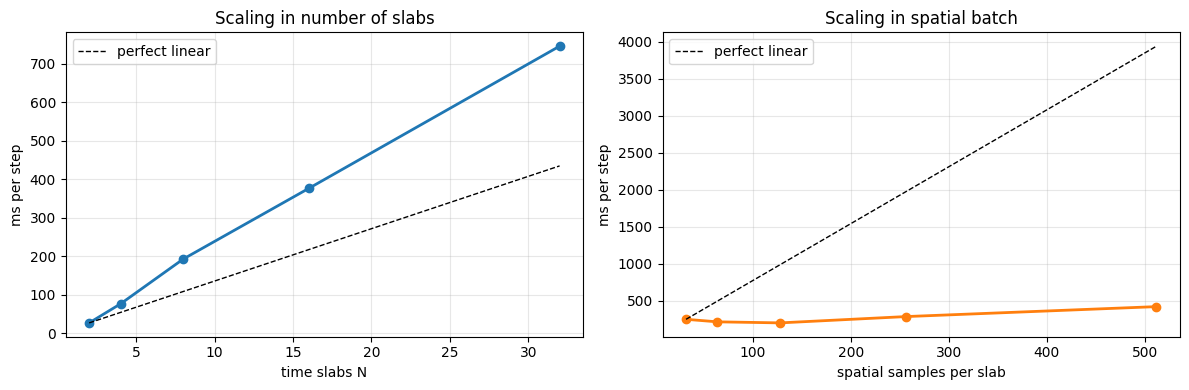

slabs   x 16 -> time x27.4
batch   x 16 -> time x1.7


In [5]:
Ns = [2, 4, 8, 16, 32]
n_xs = [32, 64, 128, 256, 512]

t_by_N = []
for N in Ns:
    model, fn = make_loss(N=N)
    t_by_N.append(time_step(fn, model) * 1e3)

t_by_x = []
for nx in n_xs:
    model, fn = make_loss(n_x=nx)
    t_by_x.append(time_step(fn, model) * 1e3)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(Ns, t_by_N, "o-", lw=2)
a1.plot(Ns, [t_by_N[0] * n / Ns[0] for n in Ns], "k--", lw=1, label="perfect linear")
a1.set_xlabel("time slabs N")
a1.set_ylabel("ms per step")
a1.set_title("Scaling in number of slabs")
a1.grid(alpha=0.3)
a1.legend()

a2.plot(n_xs, t_by_x, "o-", lw=2, color="tab:orange")
a2.plot(n_xs, [t_by_x[0] * n / n_xs[0] for n in n_xs], "k--", lw=1, label="perfect linear")
a2.set_xlabel("spatial samples per slab")
a2.set_ylabel("ms per step")
a2.set_title("Scaling in spatial batch")
a2.grid(alpha=0.3)
a2.legend()
plt.tight_layout()
plt.show()

print(f"slabs   x{Ns[-1] // Ns[0]:>3} -> time x{t_by_N[-1] / t_by_N[0]:.1f}")
print(f"batch   x{n_xs[-1] // n_xs[0]:>3} -> time x{t_by_x[-1] / t_by_x[0]:.1f}")

Slab scaling is close to linear, as expected: `forward` loops over slabs and the work per
slab is fixed. Batch scaling is typically *sub*-linear at small sizes, where per-call
overhead dominates and the matrix multiplications have not yet saturated the hardware —
which is the practical argument for a larger `n_x_train` when memory allows.

## 3. Memory

On CPU there is no allocator counter equivalent to `torch.cuda.max_memory_allocated`, so
this estimates the live autograd graph by summing the tensors reachable from the loss.
It is an approximation, and labelled as one.

In [6]:
def graph_tensor_bytes(loss):
    """Approximate bytes held by tensors saved in the autograd graph."""
    seen, total, stack = set(), 0, [loss.grad_fn]
    while stack:
        node = stack.pop()
        if node is None or id(node) in seen:
            continue
        seen.add(id(node))
        for attr in dir(node):
            if attr.startswith("_saved"):
                try:
                    val = getattr(node, attr)
                except (RuntimeError, AttributeError):
                    continue
                if torch.is_tensor(val) and id(val) not in seen:
                    seen.add(id(val))
                    total += val.element_size() * val.nelement()
        stack.extend(nxt for nxt, _ in node.next_functions)
    return total


print(f"{'N':>4} {'n_x':>6} {'graph MiB':>11} {'params MiB':>12}")
print("-" * 36)
for N, nx in ((4, 64), (8, 96), (8, 256), (16, 256)):
    model, fn = make_loss(N=N, n_x=nx)
    loss = fn()
    graph = graph_tensor_bytes(loss) / 2**20
    params = sum(p.numel() * p.element_size() for p in model.parameters()) / 2**20
    print(f"{N:>4} {nx:>6} {graph:11.2f} {params:12.3f}")

if HAS_CUDA:
    torch.cuda.reset_peak_memory_stats()
    model, fn = make_loss(N=8, n_x=256, device=torch.device("cuda"))
    fn().backward()
    torch.cuda.synchronize()
    print(f"\ncuda peak allocated: {torch.cuda.max_memory_allocated() / 2**20:.1f} MiB")

   N    n_x   graph MiB   params MiB
------------------------------------
   4     64        0.00        0.216
   8     96        0.00        0.216


   8    256        0.00        0.216


  16    256        0.00        0.216


The parameter count is negligible; memory is dominated by the autograd graph, which
grows with `N * n_x` because every slab keeps its stage evaluations alive until the
backward pass. That is the knob to turn first if you hit a memory limit.

## 4. CPU vs GPU

These problems are small — a 96-wide 4-layer MLP over a few hundred points — so kernel
launch overhead can easily dominate and a GPU may well be *slower*. Reporting that
honestly is more useful than implying a speed-up that isn't there.

In [7]:
if HAS_CUDA:
    cuda = torch.device("cuda")
    print(f"{'n_x':>6} {'CPU ms':>10} {'GPU ms':>10} {'speed-up':>10}")
    print("-" * 40)
    for nx in (64, 256, 1024, 4096):
        mc, fc = make_loss(n_x=nx, device=CPU)
        mg, fg = make_loss(n_x=nx, device=cuda)
        tc = time_step(fc, mc, device=CPU) * 1e3
        tg = time_step(fg, mg, device=cuda) * 1e3
        print(f"{nx:>6} {tc:9.1f} {tg:9.1f} {tc / tg:9.2f}x")
else:
    print("No CUDA device available; skipping.")
    print("On CPU, thread count is the lever that matters:")
    for threads in (1, max(1, torch.get_num_threads() // 2), torch.get_num_threads()):
        torch.set_num_threads(threads)
        model, fn = make_loss(n_x=256)
        print(f"  {threads:>2} thread(s): {time_step(fn, model) * 1e3:7.1f} ms")
    torch.set_num_threads(torch.get_num_threads())

No CUDA device available; skipping.
On CPU, thread count is the lever that matters:


   1 thread(s):   189.5 ms


   8 thread(s):   134.4 ms


  16 thread(s):   301.8 ms


## 5. Accuracy per unit cost

This is the measurement that justifies the whole design. Since all three tableaux cost
the same, the fair comparison is *consistency at equal cost*.

Feeding the exact solution through the residual isolates truncation error: the true
solution makes the residual vanish, so whatever remains is the method's own error. The
update residual converges at each tableau's classical order.

tableau     measured order   classical p
----------------------------------------
gauss2                3.97             4
radau2                2.97             3
lobatto2              1.97             2


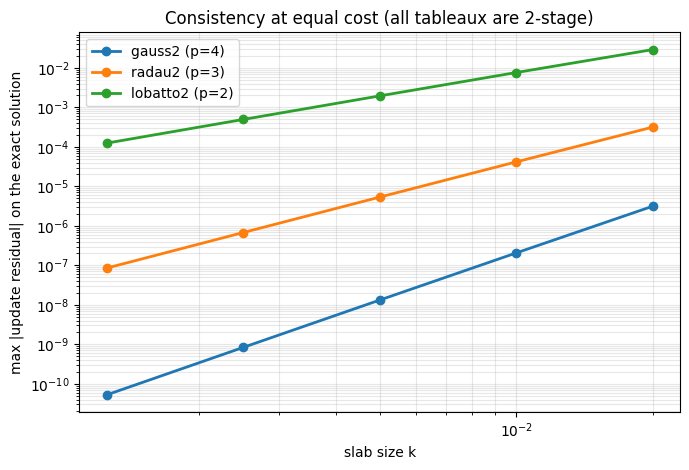

In [8]:
class ExactSolution(torch.nn.Module):
    def forward(self, x, t):
        return exact_u(x, t)


def update_residual(tableau, N, nx=48):
    cfg = RkPinnConfig(
        tableau=TABLEAUX[tableau](CPU),
        time_mesh=TimeMesh.uniform(T=0.1, N=N, device=CPU),
        residual="rk",
        n_x_train=nx,
        device=CPU,
    )
    fn = RkPinnLoss(model=ExactSolution(), Lop=Laplacian1D(), f_rhs=zero_rhs, cfg=cfg)
    x = torch.linspace(0.05, 0.95, nx).unsqueeze(1)
    _, r_step = fn.rk_residuals(x, 0, cfg.time_mesh.steps[0], fn._stage_times(0))
    return float(r_step.detach().abs().max())


slab_counts = [5, 10, 20, 40, 80]
ks = [0.1 / n for n in slab_counts]

fig, ax = plt.subplots(figsize=(7, 4.8))
print(f"{'tableau':10} {'measured order':>15} {'classical p':>13}")
print("-" * 40)
for name in TABLEAUX:
    errs = [update_residual(name, n) for n in slab_counts]
    ax.loglog(ks, errs, "o-", lw=2, label=f"{name} (p={CLASSICAL_ORDER[name]})")
    lo = torch.tensor([math.log(e) for e in errs])
    lk = torch.tensor([math.log(k) for k in ks])
    order = float(((lk - lk.mean()) * (lo - lo.mean())).sum() / ((lk - lk.mean()) ** 2).sum())
    print(f"{name:10} {order:15.2f} {CLASSICAL_ORDER[name]:13d}")

ax.set_xlabel("slab size k")
ax.set_ylabel("max |update residual| on the exact solution")
ax.set_title("Consistency at equal cost (all tableaux are 2-stage)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

Each tableau recovers its own classical order — 4, 3 and 2 — for identical cost per
step. That is only possible because the residual uses the Butcher matrix `A`; before
that, all three sat at a uniform order 2 and the choice of tableau bought nothing.

**Read this correctly.** Consistency bounds what a *perfectly trained* network could
achieve. It does not predict optimisation, and in short training runs the ranking does
not reliably follow these curves. Cheap accuracy is available here, but only to the
extent the optimiser can reach it.

## Practical summary

| lever | effect |
| --- | --- |
| `tableau` | free accuracy: same cost, orders 4 / 3 / 2. Prefer `gauss2` when smooth, `radau2` when stiff |
| `N` (slabs) | cost grows linearly; accuracy improves as $k^p$ |
| `n_x_train` | sub-linear cost at small sizes — raise it before raising `N` |
| `width` / `depth` | dominates the autograd graph, and therefore memory |
| `residual` | `"rk"` for the method's own order; `"interpolant"` for comparison |
| `ic_weight` | rebalances the initial-condition penalty against the PDE residual |